# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : torch


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\jhonp\scikit_learn_data


X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:**

$64 \times 64 = \mathbf{4096}$ valores por ejemplo.

---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


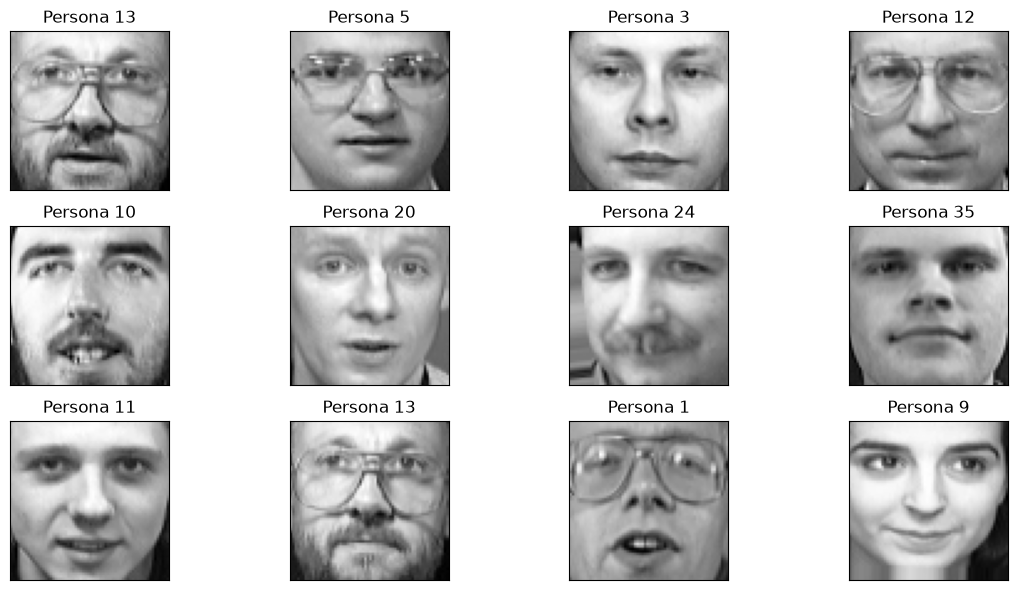

In [4]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [5]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

Porque `Dense` espera un **vector** de entrada y cada cara es una matriz de $64\times64$. `Flatten()` la reorganiza en 4096 valores, sin aprender parámetros, para que cada una de las 64 neuronas ocultas reciba todos los píxeles (4096 pesos + 1 sesgo por neurona).

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:**

Porque hay **40 personas (clases)**. Cada neurona de salida produce el logit de una identidad, y la predicción es la persona con el logit más alto.

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:**

Aporta **no linealidad**, $\max(0,x)$. Sin ella, las dos capas `Dense` colapsarían en una única transformación lineal. Con ReLU, la capa oculta puede aprender combinaciones no lineales de píxeles (rasgos faciales) que separan mejor a las personas.

---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [7]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

print("✓ Modelo configurado.")


✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:**

Porque la última capa `Dense(40)` no tiene activación: produce **logits**, no probabilidades. Con `from_logits=True`, la pérdida aplica internamente Softmax + cross-entropy de forma numéricamente estable. Si se pusiera `False`, la pérdida trataría los logits como probabilidades y el entrenamiento sería incorrecto.

---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [8]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)


Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0000e+00 - loss: 4.0808

 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0188 - loss: 4.0237    

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0156 - loss: 3.8581

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0156 - loss: 3.8581 - val_accuracy: 0.0000e+00 - val_loss: 3.6793


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0500 - loss: 3.4830 - val_accuracy: 0.0500 - val_loss: 3.4863


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0625 - loss: 3.5702

 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0417 - loss: 3.4829

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0500 - loss: 3.4767 - val_accuracy: 0.0500 - val_loss: 3.4812


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:**

Una **epoch** es una pasada completa por las **320 imágenes** de entrenamiento. Con `epochs=30`, el modelo ve cada imagen 30 veces.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:**

Que cada actualización de parámetros usa **32 imágenes**: se promedia el gradiente de la pérdida sobre esas 32 y Adam actualiza los pesos. Con 320 imágenes hay $320/32 = 10$ actualizaciones por epoch, es decir, solo **300 actualizaciones** en todo el entrenamiento.

---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


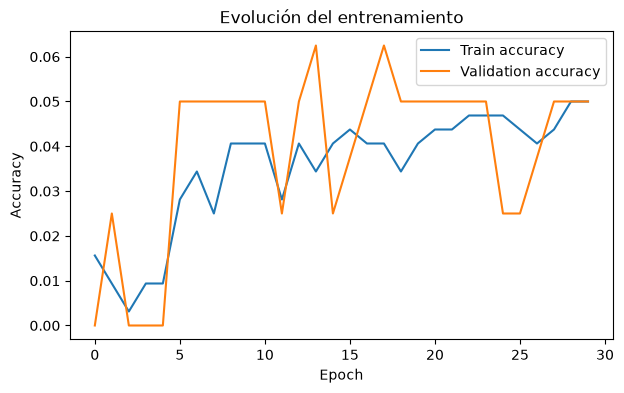

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:**

- **¿El accuracy de entrenamiento sigue aumentando?** Muy poco: pasa de ≈ 1.6 % a solo **5 %** en la epoch 30. La train loss baja lentamente, de 3.86 a 3.48 ($\ln 40 \approx 3.69$ es la pérdida de adivinar al azar).
- **¿La validación se comporta igual?** Sí: oscila entre 0 % y 6 % y termina en **5 %**. La val loss baja en paralelo (3.68 → 3.48).
- **¿Hay overfitting?** **No.** Ambas curvas están prácticamente superpuestas y muy bajas: es un caso de **underfitting severo**. La red casi no aprendió, ni siquiera en los datos de entrenamiento.

**¿Por qué?** Revisando la capa oculta después del entrenamiento, **≈ 98 % de las 64 neuronas ReLU están "muertas"**: dan 0 para todas las imágenes. Los píxeles están en $[0,1]$, **no están centrados** y están muy correlados entre sí (todas las caras tienen un brillo parecido). Adam mueve cada uno de los 4096 pesos de una neurona en la misma dirección, de modo que la pre-activación se desplaza mucho en los primeros pasos, se vuelve negativa para todas las imágenes y ReLU queda en 0, con gradiente 0. Sin capa oculta útil, la red solo aprende un sesgo y termina prediciendo casi siempre la misma persona (en la visualización, 10 de las 12 predicciones son "Persona 5"). Pasa lo mismo con otras semillas (0, 1 y 7).

*Verificación aparte, sin modificar el notebook:* si a la misma red se le dan las imágenes **estandarizadas** ($(x-\mu)/\sigma$, con $\mu$ y $\sigma$ de train), en 30 epochs llega a **100 % en train y 93.8 % en validación** (train loss 0.003 vs val loss 0.26). Ahí sí aparece el **overfitting** que se esperaba ver: la red memoriza el entrenamiento y queda una brecha clara con validación.

---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [10]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 3.4812
Test accuracy : 0.0500
Accuracy (%)  : 5.00%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:**

Es una cantidad **muy pequeña**. La red tiene **264 808 parámetros** y solo **320 imágenes** de entrenamiento: unos 830 parámetros por ejemplo, con apenas **8 imágenes por persona**. Con tan pocos datos, una red así puede **memorizar** cada imagen de entrenamiento en lugar de aprender rasgos generales de cada rostro, y queda muy expuesta al overfitting. En este caso, además, el entrenamiento ni siquiera logró aprovechar esa capacidad (5 % de accuracy, por las neuronas muertas). Para este tamaño de dataset convendría un modelo más pequeño, regularización (Dropout, L2), data augmentation o features preentrenadas (transfer learning).

---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


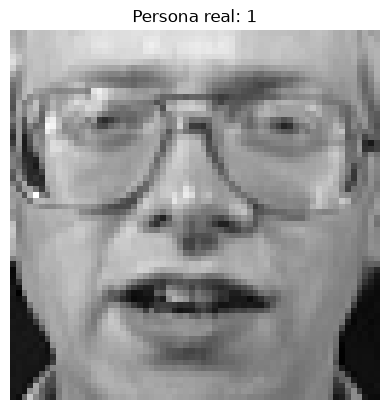

Shape de logits: torch.Size([1, 40])

Primeros 10 logits:
[ 0.24583292  0.33802915 -0.2424851  -0.43469986  0.5255413   0.67663956
  0.59201777 -0.40596536 -0.8692906  -0.83788544]


In [11]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [12]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)



Persona real     : 1
Persona predicha : 5


In [13]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona  5: 0.0510
Persona 23: 0.0501
Persona 30: 0.0474
Persona  6: 0.0468
Persona 33: 0.0461

Suma de probabilidades: 0.9999999


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:**

Porque Softmax divide cada exponencial por la suma de todas: $P_k=e^{z_k}/\sum_{j=1}^{40}e^{z_j}$. Todas son positivas y su suma es exactamente 1, así que forman una distribución de probabilidad sobre las 40 personas. La suma impresa (0.9999999) no es exactamente 1 por el redondeo de `float32`.

En este caso, además, las probabilidades del top 5 son casi uniformes (≈ 0.05 cada una, cerca de $1/40 = 0.025$): el modelo **no está seguro** de ninguna persona, coherente con lo poco que aprendió.

---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


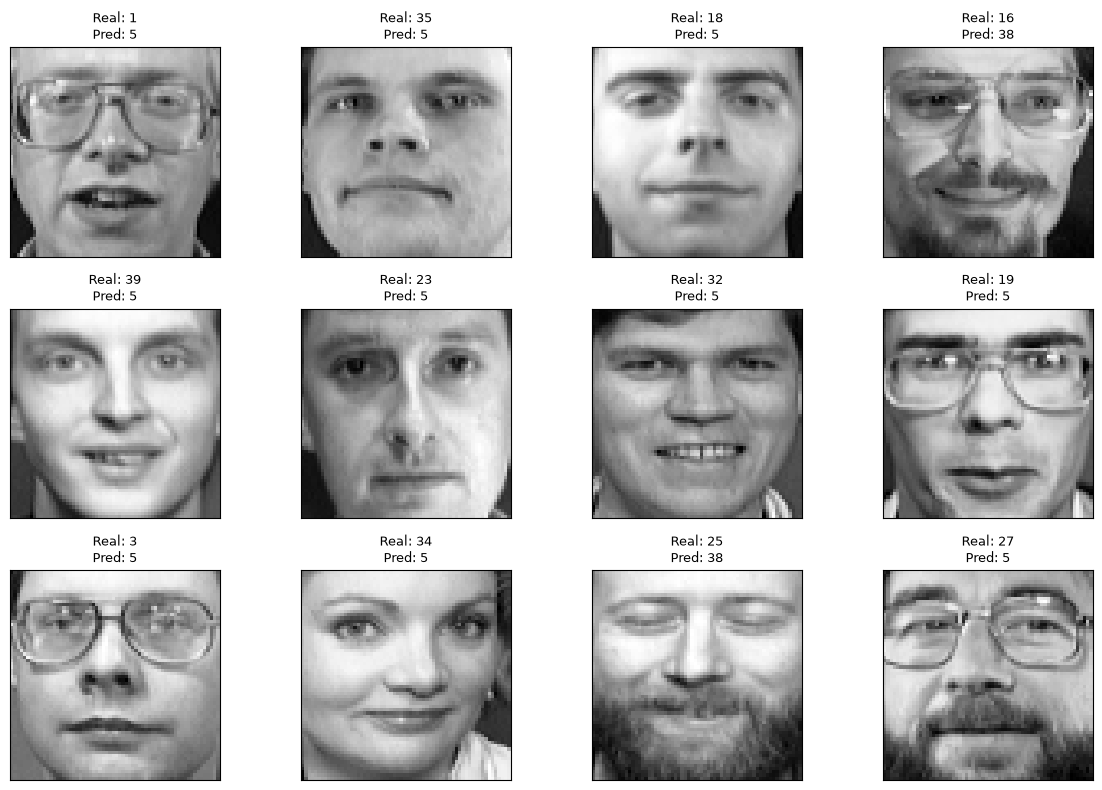

In [14]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:**

**5 %** de accuracy en test (4 de 80 caras), con test loss 3.48. Es apenas el doble del azar ($1/40 = 2.5\,\%$).

### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:**

**No**, en esta ejecución no hubo overfitting sino **underfitting**. La evidencia: train y validation accuracy se mantienen juntas y muy bajas (≈ 5 %), y las dos pérdidas bajan en paralelo y siguen cerca de $\ln 40$. Si hubiera overfitting, train accuracy sería alta y validación quedaría claramente por debajo. La causa es que casi todas las neuronas ReLU murieron con entradas sin centrar (ver Pregunta 8). Con entradas estandarizadas, la misma red sí sobreajusta: 100 % en train frente a 93.8 % en validación.

### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:**

El modelo tiene capacidad de sobra para **memorizar** los ejemplos de entrenamiento, incluido su ruido (iluminación, expresión concreta), en lugar de aprender patrones que generalicen. Se ve cuando train accuracy llega a ~100 % mientras validación se queda más abajo y la val loss deja de bajar o sube. Además, las estimaciones son más **inestables** y sensibles a la inicialización y a la partición. Para mitigarlo: más datos o data augmentation, regularización (Dropout, L2, early stopping), modelos más pequeños o con sesgo inductivo adecuado (CNNs), o transfer learning.

### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:**

Deja de representar explícitamente la **vecindad 2D** entre píxeles: qué píxeles están arriba, abajo o al lado de otros. También pierde la **forma y las relaciones espaciales** entre partes del rostro (los ojos sobre la nariz, la boca debajo) y los **patrones locales** (bordes, contornos, texturas). La red tendría que aprender esas relaciones desde cero con pesos independientes por píxel, y no es invariante a pequeños desplazamientos o giros de la cara.

### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:**

Sí. Las **CNNs** usan filtros locales que comparten pesos en toda la imagen, así que detectan el mismo patrón (un ojo, un borde) en cualquier posición con muchos menos parámetros. Las capas se componen de forma jerárquica (bordes → rasgos → rostro). Ese sesgo inductivo es justo lo que falta con tan pocos datos: menos parámetros y más estructura reducen el overfitting y mejoran la generalización.

---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**

---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
